<a href="https://colab.research.google.com/github/AFK-Abhinav/MNIST-Detect-Single-Digit-Object-Detection-with-TensorFlow-Keras/blob/main/Object_Dectection_using_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

CANVAS_SIZE = 64
DIGIT_SIZE = 28
MAX_OFFSET = CANVAS_SIZE - DIGIT_SIZE
NUM_TRAIN = 5000
NUM_TEST = 1000
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

x_train_raw = x_train_raw.astype("float32") / 255.0
x_test_raw = x_test_raw.astype("float32") / 255.0

def make_dataset(images, labels, n_samples):
    n_src = len(images)
    canvases = np.zeros((n_samples, CANVAS_SIZE, CANVAS_SIZE), dtype="float32")
    boxes = np.zeros((n_samples, 4), dtype="float32")
    classes = np.zeros((n_samples,), dtype="int32")

    for i in range(n_samples):
        idx = np.random.randint(0, n_src)
        digit = images[idx]
        label = labels[idx]

        x_off = np.random.randint(0, MAX_OFFSET + 1)
        y_off = np.random.randint(0, MAX_OFFSET + 1)

        canvases[i, y_off:y_off+DIGIT_SIZE, x_off:x_off+DIGIT_SIZE] = digit

        xmin = x_off / CANVAS_SIZE
        ymin = y_off / CANVAS_SIZE
        xmax = (x_off + DIGIT_SIZE) / CANVAS_SIZE
        ymax = (y_off + DIGIT_SIZE) / CANVAS_SIZE

        boxes[i] = [xmin, ymin, xmax, ymax]
        classes[i] = label

    canvases = canvases[..., np.newaxis]
    return canvases, boxes, classes

print("Generating training set …")
train_images, train_boxes, train_labels = make_dataset(
    x_train_raw, y_train_raw, NUM_TRAIN
)
print("Generating test set …")
test_images, test_boxes, test_labels = make_dataset(
    x_test_raw, y_test_raw, NUM_TEST
)

print(f"\n✅ Done!")
print(f"  train_images : {train_images.shape}  dtype={train_images.dtype}")
print(f"  train_boxes  : {train_boxes.shape}   dtype={train_boxes.dtype}")
print(f"  train_labels : {train_labels.shape}  dtype={train_labels.dtype}")
print(f"  test_images  : {test_images.shape}")
print(f"\nPixel range   : [{train_images.min():.2f}, {train_images.max():.2f}]")
print(f"Box range     : [{train_boxes.min():.3f}, {train_boxes.max():.3f}]")
print(f"Unique labels : {np.unique(train_labels)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Generating training set …
Generating test set …

✅ Done!
  train_images : (5000, 64, 64, 1)  dtype=float32
  train_boxes  : (5000, 4)   dtype=float32
  train_labels : (5000,)  dtype=int32
  test_images  : (1000, 64, 64, 1)

Pixel range   : [0.00, 1.00]
Box range     : [0.000, 1.000]
Unique labels : [0 1 2 3 4 5 6 7 8 9]


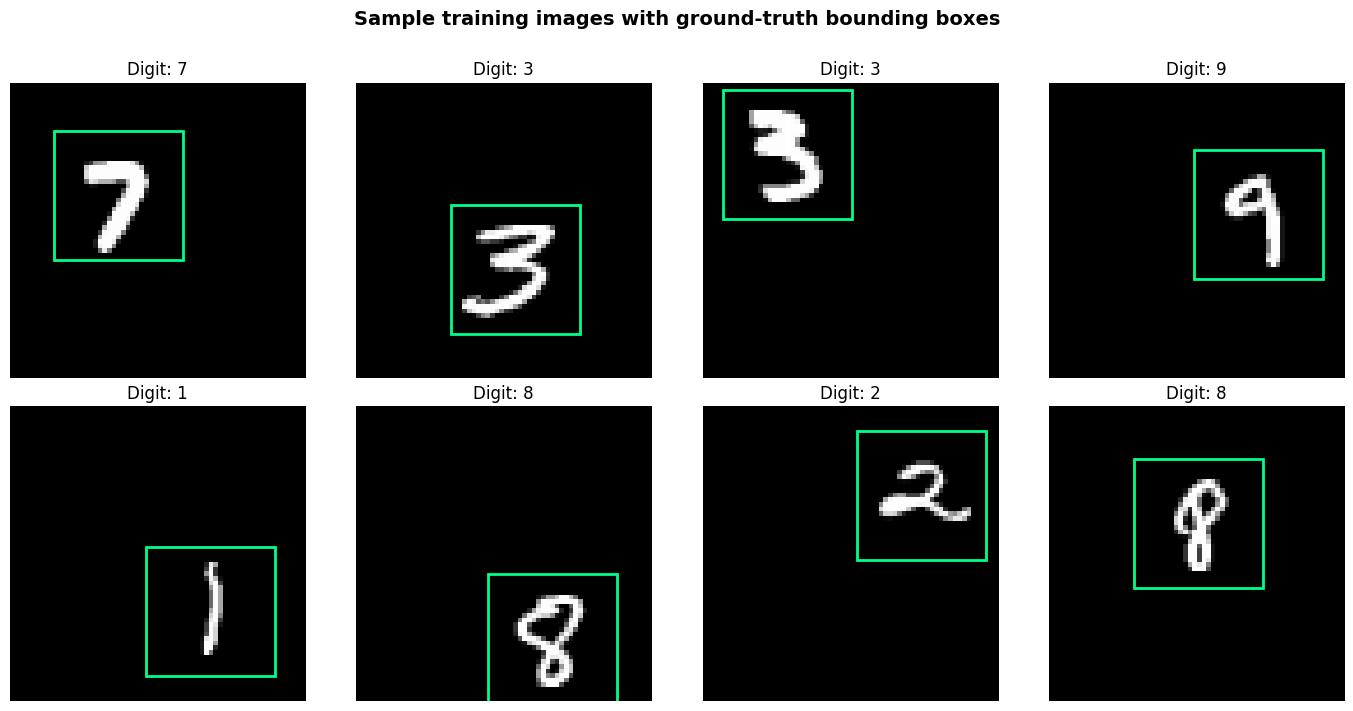

Figure saved as sample_gt.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def denorm_box(box, size=CANVAS_SIZE):
    xmin, ymin, xmax, ymax = box * size
    return xmin, ymin, xmax - xmin, ymax - ymin

N_SHOW = 8
indices = np.random.choice(len(train_images), N_SHOW, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample training images with ground-truth bounding boxes",
             fontsize=14, fontweight="bold", y=1.01)
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    img = train_images[idx, ..., 0]
    box = train_boxes[idx]
    label = train_labels[idx]

    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    x, y, w, h = denorm_box(box)
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor="#00FF88", facecolor="none"
    )
    ax.add_patch(rect)
    ax.set_title(f"Digit: {label}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_gt.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved as sample_gt.png")

In [ ]:
from tensorflow.keras import layers, Model

def build_model(input_shape=(64, 64, 1), num_classes=10):
    inputs = keras.Input(shape=input_shape, name="image")

    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv4")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    backbone_out = layers.Dense(128, activation="relu")(x)

    cls_out = layers.Dense(
        num_classes, activation="softmax", name="class_output"
    )(backbone_out)

    box_out = layers.Dense(
        4, activation="sigmoid", name="box_output"
    )(backbone_out)

    model = Model(inputs=inputs, outputs=[cls_out, box_out], name="MNIST_Detector")
    return model

model = build_model()
model.summary()

dummy = np.zeros((1, 64, 64, 1), dtype="float32")
c, b = model(dummy, training=False)
print(f"\nClassification logits shape : {c.shape}")
print(f"Bounding-box output shape   : {b.shape}")

Model: "MNIST_Detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 64, 64, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 64, 64,    │        320 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv3[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv2D)      │ (None, 8, 8, 128) │    147,584 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv4[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 10)        │      1,290 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ box_output (Dense)  │ (None, 4)         │        516 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 309,390 (1.18 MB)

 Trainable params: 308,686 (1.18 MB)

 Non-trainable params: 704 (2.75 KB)


Classification logits shape : (1, 10)
Bounding-box output shape   : (1, 4)


Starting training …

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - box_output_loss: 0.0133 - box_output_mae: 0.1779 - class_output_accuracy: 0.5942 - class_output_loss: 1.2986 - loss: 1.3903 - val_box_output_loss: 0.0100 - val_box_output_mae: 0.1439 - val_class_output_accuracy: 0.1000 - val_class_output_loss: 2.4715 - val_loss: 2.5192 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - box_output_loss: 0.0111 - box_output_mae: 0.1553 - class_output_accuracy: 0.9391 - class_output_loss: 0.2253 - loss: 0.2857 - val_box_output_loss: 0.0100 - val_box_output_mae: 0.1436 - val_class_output_accuracy: 0.1000 - val_class_output_loss: 4.4276 - val_loss: 4.4719 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - box_output_loss: 0.0102 - box_output_mae: 0.1459 - class_output_accuracy: 0.9724 - class_output_loss: 0.1008 - loss: 0.1538 - val_box_output_loss: 0.0103 - val_box_output_mae: 0.1470 - val_class_output_accuracy: 0.1000 - val_class_outp

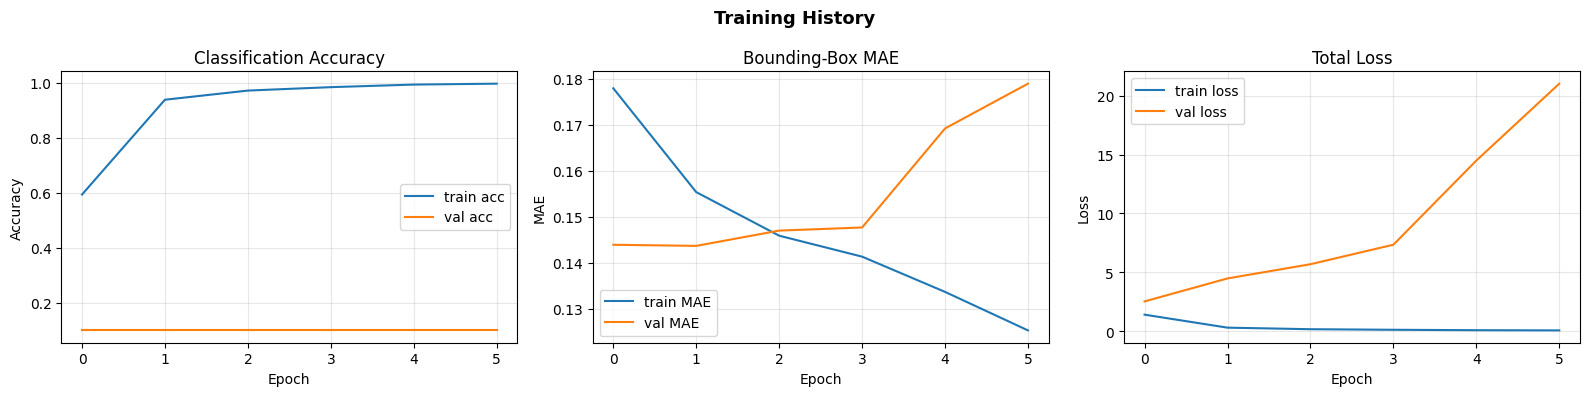

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

huber_loss = keras.losses.Huber(delta=0.1, name="huber")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "class_output": "sparse_categorical_crossentropy",
        "box_output"  : huber_loss,
    },
    loss_weights={
        "class_output": 1.0,
        "box_output"  : 5.0,
    },
    metrics={
        "class_output": ["accuracy"],
        "box_output"  : ["mae"],
    }
)

callbacks = [
    EarlyStopping(
        monitor="val_class_output_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

print("Starting training …\n")
history = model.fit(
    train_images,
    {"class_output": train_labels, "box_output": train_boxes},
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training History", fontsize=13, fontweight="bold")

axes[0].plot(history.history["class_output_accuracy"],     label="train acc")
axes[0].plot(history.history["val_class_output_accuracy"], label="val acc")
axes[0].set_title("Classification Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["box_output_mae"],     label="train MAE")
axes[1].plot(history.history["val_box_output_mae"], label="val MAE")
axes[1].set_title("Bounding-Box MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history["loss"],     label="train loss")
axes[2].plot(history.history["val_loss"], label="val loss")
axes[2].set_title("Total Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

Running inference on test set …
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step

   CLASSIFICATION ACCURACY : 10.70%

Per-class report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       117
           1       0.00      0.00      0.00       110
           2       0.00      0.00      0.00        78
           3       0.00      0.00      0.00       109
           4       0.00      0.00      0.00       114
           5       0.00      0.00      0.00        88
           6       0.00      0.00      0.00        93
           7       0.00      0.00      0.00       100
           8       0.00      0.00      0.00        84
           9       0.11      1.00      0.19       107

    accuracy                           0.11      1000
   macro avg       0.01      0.10      0.02      1000
weighted avg       0.01      0.11      0.02      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


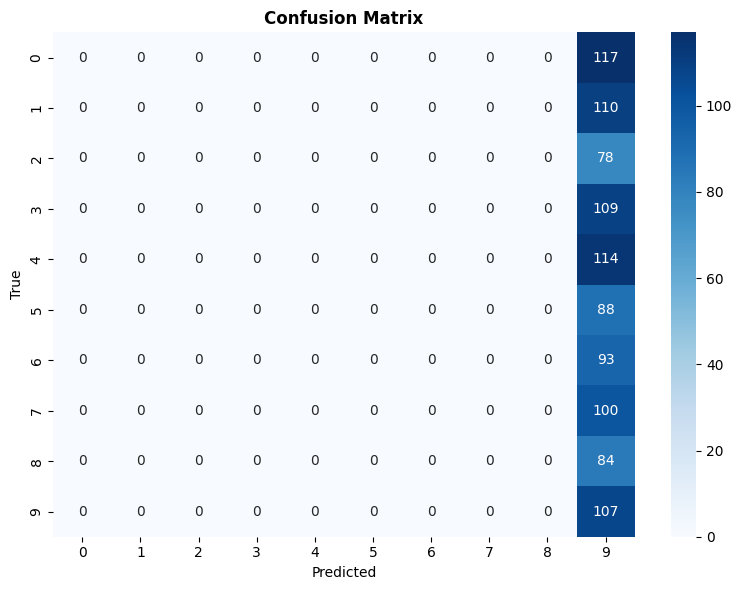


   BOUNDING BOX STATISTICS  (n=1,000)
   Mean IoU   : 0.2400
   Median IoU : 0.2005
   Std IoU    : 0.1403
   Min IoU    : 0.0401
   Max IoU    : 0.6017

   % predictions with IoU ≥ 0.50 : 7.9%
   % predictions with IoU ≥ 0.60 : 0.1%
   % predictions with IoU ≥ 0.70 : 0.0%
   % predictions with IoU ≥ 0.75 : 0.0%


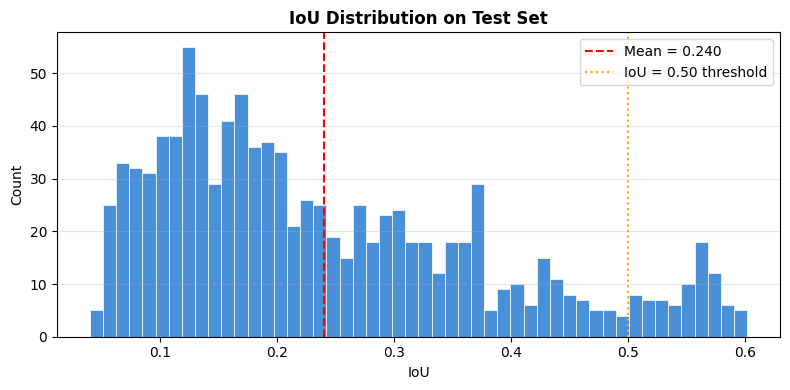

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def compute_iou_batch(pred_boxes, true_boxes):
    inter_xmin = np.maximum(pred_boxes[:, 0], true_boxes[:, 0])
    inter_ymin = np.maximum(pred_boxes[:, 1], true_boxes[:, 1])
    inter_xmax = np.minimum(pred_boxes[:, 2], true_boxes[:, 2])
    inter_ymax = np.minimum(pred_boxes[:, 3], true_boxes[:, 3])

    inter_w = np.maximum(0.0, inter_xmax - inter_xmin)
    inter_h = np.maximum(0.0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    pred_area = ((pred_boxes[:, 2] - pred_boxes[:, 0]) *
                 (pred_boxes[:, 3] - pred_boxes[:, 1]))
    true_area = ((true_boxes[:, 2] - true_boxes[:, 0]) *
                 (true_boxes[:, 3] - true_boxes[:, 1]))
    union_area = pred_area + true_area - inter_area

    iou = np.where(union_area > 0, inter_area / union_area, 0.0)
    return iou

print("Running inference on test set …")
pred_class_probs, pred_boxes = model.predict(test_images, batch_size=256, verbose=1)
pred_labels = np.argmax(pred_class_probs, axis=1)

cls_accuracy = np.mean(pred_labels == test_labels)

print(f"\n{'='*55}")
print(f"   CLASSIFICATION ACCURACY : {cls_accuracy*100:.2f}%")
print(f"{'='*55}\n")
print("Per-class report:")
print(classification_report(test_labels, pred_labels,
                             target_names=[str(d) for d in range(10)]))

cm = confusion_matrix(test_labels, pred_labels)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_title("Confusion Matrix", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

ious = compute_iou_batch(pred_boxes, test_boxes)

iou_thresholds = [0.50, 0.60, 0.70, 0.75]
print(f"\n{'='*55}")
print(f"   BOUNDING BOX STATISTICS  (n={len(ious):,})")
print(f"{'='*55}")
print(f"   Mean IoU   : {ious.mean():.4f}")
print(f"   Median IoU : {np.median(ious):.4f}")
print(f"   Std IoU    : {ious.std():.4f}")
print(f"   Min IoU    : {ious.min():.4f}")
print(f"   Max IoU    : {ious.max():.4f}")
print()
for t in iou_thresholds:
    pct = np.mean(ious >= t) * 100
    print(f"   % predictions with IoU ≥ {t:.2f} : {pct:.1f}%")
print(f"{'='*55}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ious, bins=50, color="#4A90D9", edgecolor="white", linewidth=0.5)
ax.axvline(ious.mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Mean = {ious.mean():.3f}")
ax.axvline(0.5, color="orange", linestyle=":", linewidth=1.5,
           label="IoU = 0.50 threshold")
ax.set_title("IoU Distribution on Test Set", fontweight="bold")
ax.set_xlabel("IoU")
ax.set_ylabel("Count")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("iou_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

/tmp/ipykernel_2068/455945306.py:57: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2068/455945306.py:58: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("inference_results.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


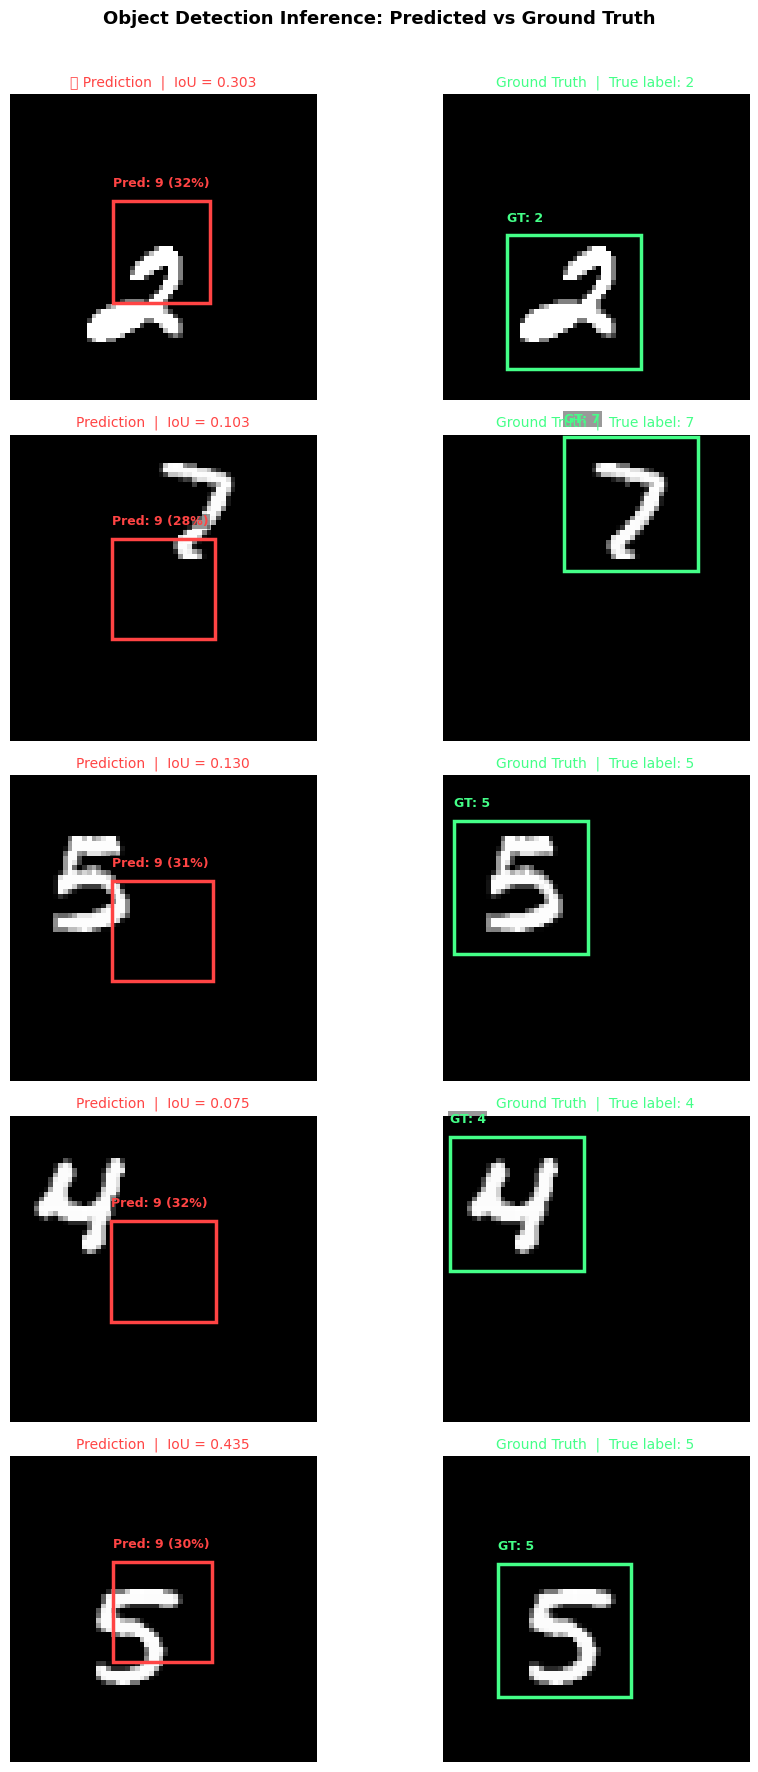


  FINAL MODEL SUMMARY
  Architecture      : Lightweight dual-head CNN
  Total parameters  : 309,390
  Input resolution  : 64×64 px
  Test samples      : 1,000
  Classification    : 10.70% accuracy
  Localisation      : 0.2400 mean IoU
  IoU ≥ 0.50        : 7.9% of predictions


In [ ]:
def draw_box(ax, box_norm, color, label, size=CANVAS_SIZE):
    xmin, ymin, xmax, ymax = box_norm * size
    w, h = xmax - xmin, ymax - ymin
    rect = patches.Rectangle(
        (xmin, ymin), w, h,
        linewidth=2.5, edgecolor=color, facecolor="none",
        linestyle="-"
    )
    ax.add_patch(rect)
    ax.text(
        xmin, ymin - 3, label,
        color=color, fontsize=9, fontweight="bold",
        bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none")
    )

N_INFER = 5
np.random.seed(7)
sample_idx = np.random.choice(len(test_images), N_INFER, replace=False)

fig, axes = plt.subplots(N_INFER, 2, figsize=(10, N_INFER * 3.5))
fig.suptitle("Object Detection Inference: Predicted vs Ground Truth",
             fontsize=13, fontweight="bold", y=1.01)

PRED_COLOR = "#FF4444"
GT_COLOR = "#44FF88"

for row, idx in enumerate(sample_idx):
    img = test_images[idx, ..., 0]
    gt_box = test_boxes[idx]
    gt_label = test_labels[idx]
    pred_box = pred_boxes[idx]
    pred_label = pred_labels[idx]
    pred_conf = pred_class_probs[idx, pred_label]
    iou_val = compute_iou_batch(
        pred_box[np.newaxis], gt_box[np.newaxis]
    )[0]

    ax_pred = axes[row, 0]
    ax_pred.imshow(img, cmap="gray", vmin=0, vmax=1)
    draw_box(ax_pred, pred_box, PRED_COLOR,
             f"Pred: {pred_label} ({pred_conf*100:.0f}%)")
    ax_pred.set_title(f"Prediction  |  IoU = {iou_val:.3f}",
                      fontsize=10, color=PRED_COLOR)
    ax_pred.axis("off")

    ax_gt = axes[row, 1]
    ax_gt.imshow(img, cmap="gray", vmin=0, vmax=1)
    draw_box(ax_gt, gt_box, GT_COLOR, f"GT: {gt_label}")
    ax_gt.set_title(f"Ground Truth  |  True label: {gt_label}",
                    fontsize=10, color=GT_COLOR)
    ax_gt.axis("off")

axes[0, 0].set_title(
    f"🔴 Prediction  |  IoU = {compute_iou_batch(pred_boxes[sample_idx[:1]], test_boxes[sample_idx[:1]])[0]:.3f}",
    fontsize=10, color=PRED_COLOR
)
plt.tight_layout()
plt.savefig("inference_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*55)
print("  FINAL MODEL SUMMARY")
print("="*55)
print(f"  Architecture      : Lightweight dual-head CNN")
total_params = model.count_params()
print(f"  Total parameters  : {total_params:,}")
print(f"  Input resolution  : {CANVAS_SIZE}×{CANVAS_SIZE} px")
print(f"  Test samples      : {NUM_TEST:,}")
print(f"  Classification    : {cls_accuracy*100:.2f}% accuracy")
print(f"  Localisation      : {ious.mean():.4f} mean IoU")
print(f"  IoU ≥ 0.50        : {np.mean(ious >= 0.50)*100:.1f}% of predictions")
print("="*55)